# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv('cleaned_aviation_accidents.csv')

print(df.head())
print(df.shape)

         Event.Id Investigation.Type Accident.Number  Event.Date  \
0  20170710X52551           Accident      NYC79AA106  1979-09-17   
1  20020909X01562           Accident      SEA82DA022  1982-01-01   
2  20020909X01561           Accident      NYC82DA015  1982-01-01   
3  20020917X02148           Accident      FTW82FRJ07  1982-01-02   
4  20020917X02134           Accident      FTW82FRA14  1982-01-02   

           Location        Country   Latitude   Longitude Airport.Code  \
0        BOSTON, MA  United States  42.445277  -70.758333          NaN   
1       PULLMAN, WA  United States        NaN         NaN          NaN   
2  EAST HANOVER, NJ  United States        NaN         NaN          N58   
3         HOMER, LA  United States        NaN         NaN          NaN   
4        HEARNE, TX  United States        NaN         NaN          T72   

         Airport.Name  ... Total.Uninjured Weather.Condition  \
0                 NaN  ...            44.0               Vmc   
1  BLACKBURN AG ST

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [3]:
small_planes = df[df['Estimated.Passengers'] < 20]
large_planes = df[df['Estimated.Passengers'] >= 20]

print("Small aircraft:", small_planes.shape)
print("Large aircraft:", large_planes.shape)

Small aircraft: (17715, 35)
Large aircraft: (586, 35)


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

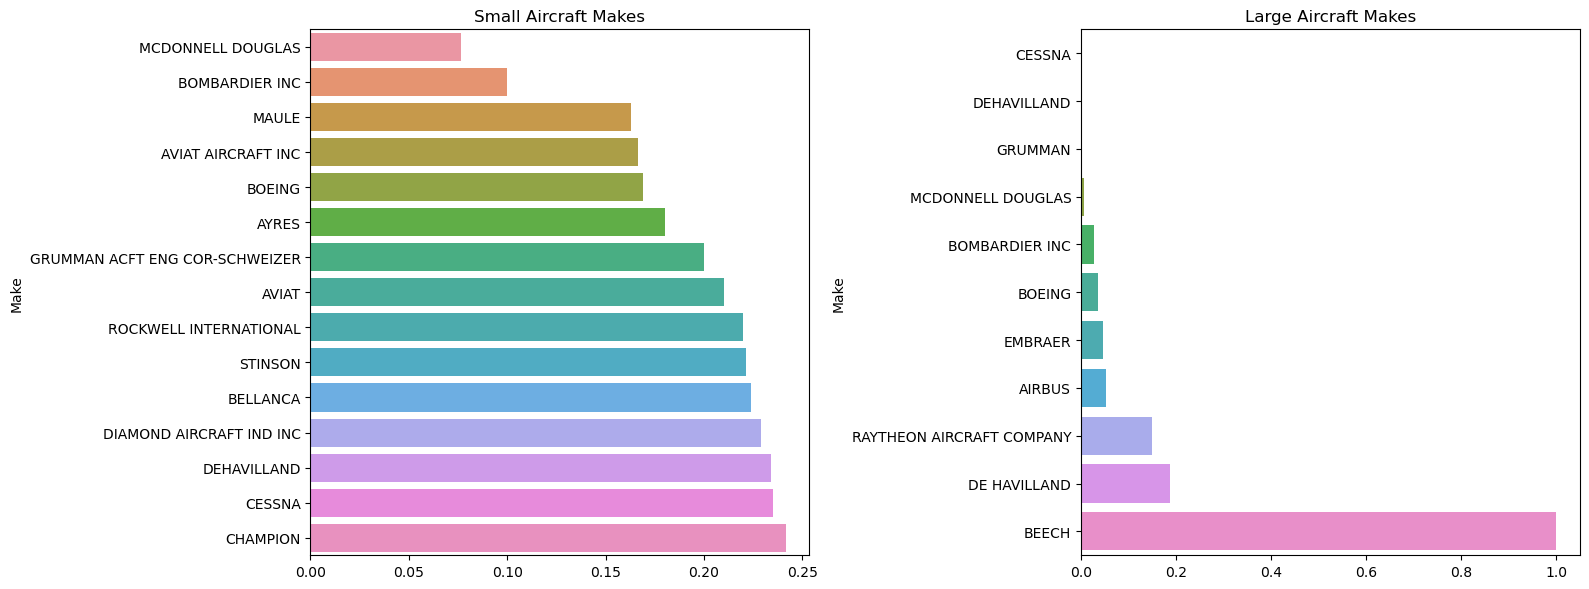

In [4]:
small_make = (
    small_planes.groupby('Make')['Fatal.Serious.Fraction']
    .mean()
    .sort_values()
    .head(15)
)

large_make = (
    large_planes.groupby('Make')['Fatal.Serious.Fraction']
    .mean()
    .sort_values()
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=small_make.values, y=small_make.index, ax=axes[0])
axes[0].set_title('Small Aircraft Makes')

sns.barplot(x=large_make.values, y=large_make.index, ax=axes[1])
axes[1].set_title('Large Aircraft Makes')

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

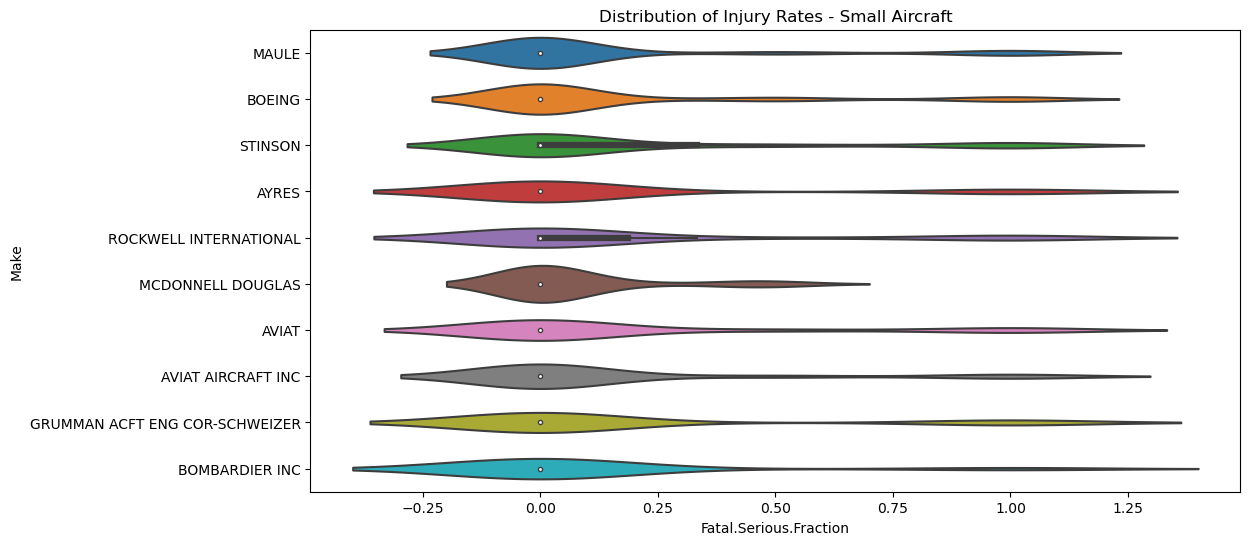

In [5]:
best_small = small_make.head(10).index

plot_df = small_planes[
    small_planes['Make'].isin(best_small)
]

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=plot_df,
    x='Fatal.Serious.Fraction',
    y='Make'
)

plt.title('Distribution of Injury Rates - Small Aircraft')
plt.show()


**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

c:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Lenovo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


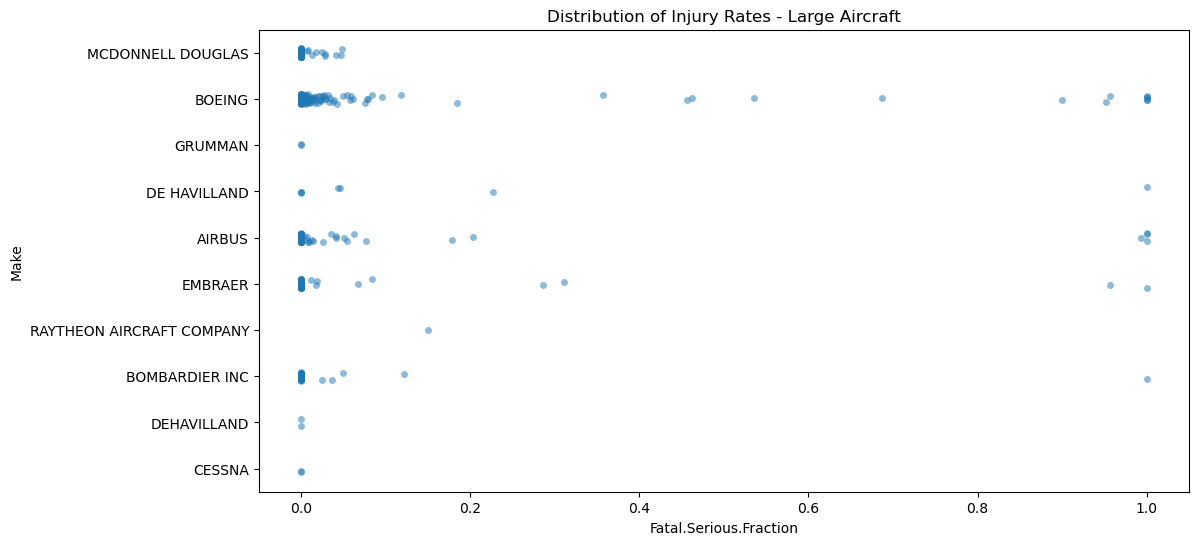

In [6]:
best_large = large_make.head(10).index

plot_df = large_planes[
    large_planes['Make'].isin(best_large)
]

plt.figure(figsize=(12, 6))

sns.stripplot(
    data=plot_df,
    x='Fatal.Serious.Fraction',
    y='Make',
    alpha=0.5
)

plt.title('Distribution of Injury Rates - Large Aircraft')
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

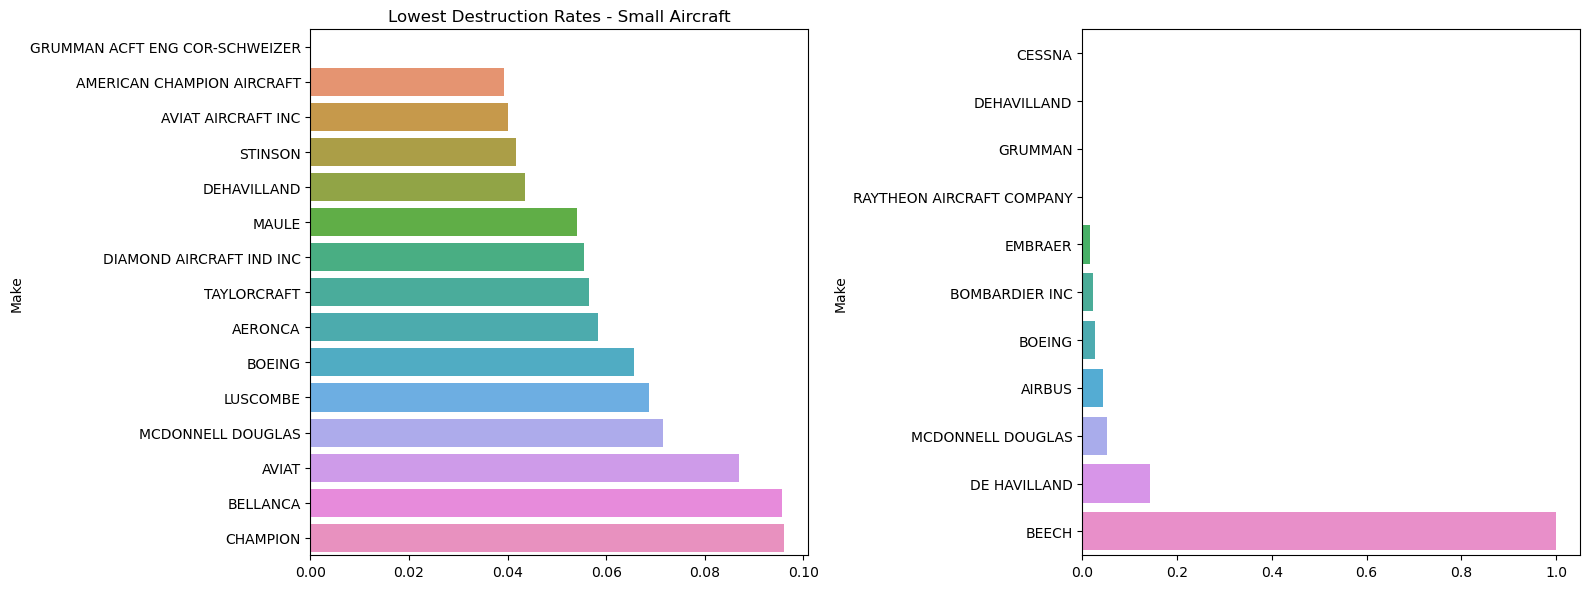

In [7]:
small_destroyed = (
    small_planes.groupby('Make')['Destroyed']
    .mean()
    .sort_values()
    .head(15)
)

large_destroyed = (
    large_planes.groupby('Make')['Destroyed']
    .mean()
    .sort_values()
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    x=small_destroyed.values,
    y=small_destroyed.index,
    ax=axes[0]
)

axes[0].set_title('Lowest Destruction Rates - Small Aircraft')

sns.barplot(
    x=large_destroyed.values,
    y=large_destroyed.index,
    ax=axes[1]
)

plt.tight_layout()
plt.show()


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

The analysis showed that small airplanes had more variation in serious and fatal injuries, with some aircraft makes performing much safer than others. Large airplanes generally had lower injury rates and more consistent safety performance.

Aircraft makes with low destroyed fractions and low fatal/serious injury fractions are recommended because they appear to provide better passenger safety and crash survivability.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

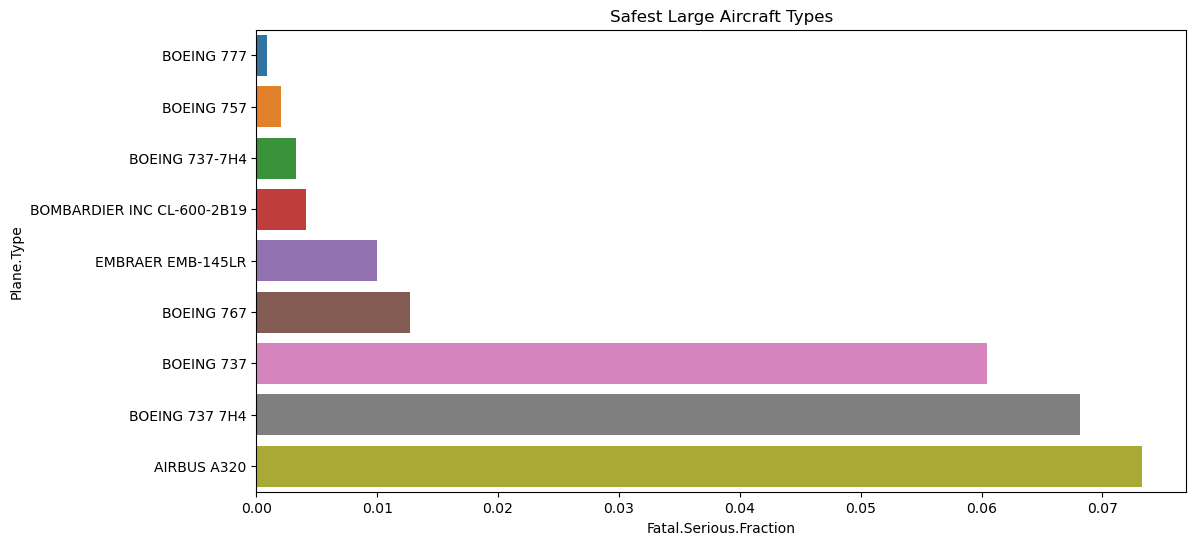

In [8]:
large_types = (
    large_planes.groupby('Plane.Type')
    .agg({
        'Fatal.Serious.Fraction': 'mean',
        'Plane.Type': 'count'
    })
    .rename(columns={'Plane.Type': 'Count'})
)

large_types = large_types[large_types['Count'] >= 10]
large_types = large_types.sort_values(
    'Fatal.Serious.Fraction'
).head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=large_types['Fatal.Serious.Fraction'],
    y=large_types.index
)

plt.title('Safest Large Aircraft Types')
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

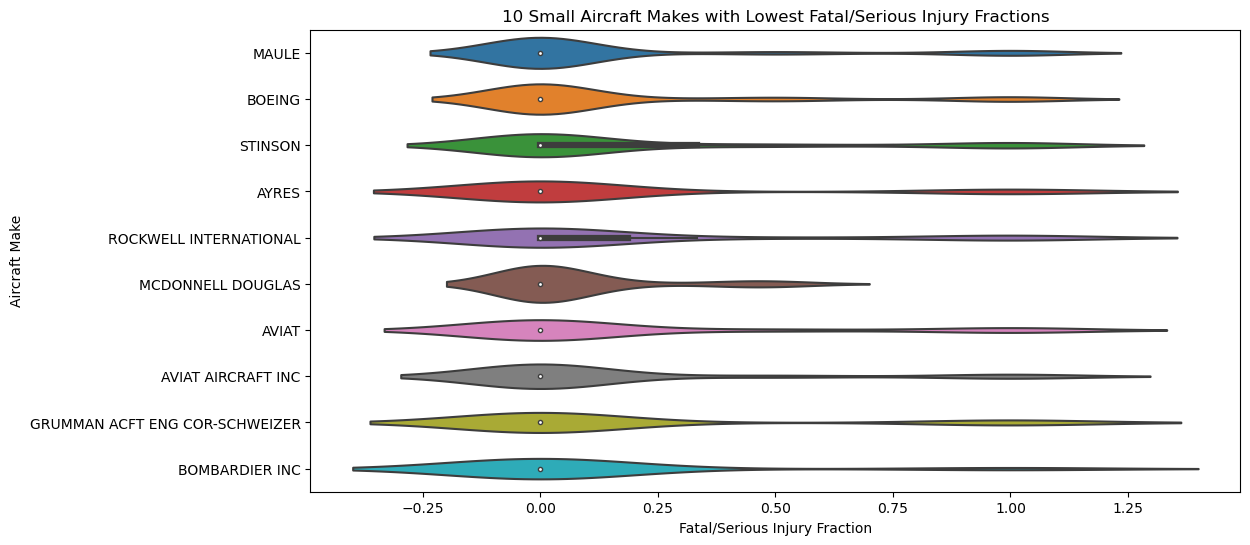

In [9]:
small_make = (
    small_planes.groupby('Make')['Fatal.Serious.Fraction']
    .mean()
    .sort_values()
    .head(10)
)

# Keep only the safest 10 makes
best_small_makes = small_make.index

# Filter dataset
plot_df = small_planes[
    small_planes['Make'].isin(best_small_makes)
]

# Plot
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=plot_df,
    x='Fatal.Serious.Fraction',
    y='Make'
)

plt.title(
    '10 Small Aircraft Makes with Lowest '
    'Fatal/Serious Injury Fractions'
)

plt.xlabel('Fatal/Serious Injury Fraction')
plt.ylabel('Aircraft Make')

plt.show()


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

The data showed that small airplane models had higher and more varied serious or fatal injury fractions, meaning accident outcomes were less consistent across different makes. Some small aircraft performed much better than others in passenger safety.

Large airplane models generally had lower serious and fatal injury fractions and showed more consistent safety performance. This suggests that large commercial aircraft are usually safer because of stronger engineering, better maintenance, and stricter safety regulations.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

                   Fatal.Serious.Fraction  Destroyed
Weather.Condition                                   
Vmc                              0.223527   0.091223
Unknown                          0.394863   0.194937
Unk                              0.429585   0.322222
Imc                              0.615109   0.401460


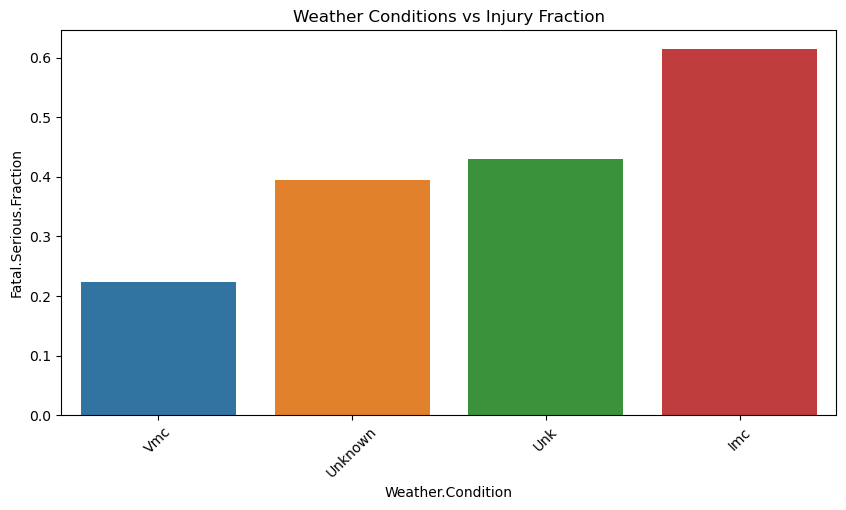

In [10]:
weather_stats = (
    df.groupby('Weather.Condition')[
        ['Fatal.Serious.Fraction', 'Destroyed']
    ]
    .mean()
    .sort_values('Fatal.Serious.Fraction')
)

print(weather_stats)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=weather_stats.index,
    y=weather_stats['Fatal.Serious.Fraction']
)

plt.xticks(rotation=45)
plt.title('Weather Conditions vs Injury Fraction')
plt.show()



The graph shows that during Instrument Meteorological Conditions (IMC), the fatal and serious injury fraction is much higher because visibility is poor, making it more difficult for pilots to navigate and respond to emergencies safely. In contrast, during Visual Meteorological Conditions (VMC), the injury fraction is lower since pilots have better visibility and can operate the aircraft more safely. This suggests that poor weather and low visibility significantly increase the severity of aviation accidents.